In [1]:
import radiate as rd
import polars as pl

rd.random.seed(67123)

In [2]:
def compute(x: float) -> float:
    return 4.0 * x**3 - 3.0 * x**2 + x


inputs = []
answers = []

input = -1.0
for _ in range(-10, 10):
    input += 0.1
    inputs.append([input])
    answers.append([compute(input)])

In [3]:
target_species = 4.0
rolling = int(target_species)

anchor = rd.select("species.distance").max().rolling(rolling).mean()
count_error = (
    rd.select("count.species").rolling(rolling).mean() - target_species
) / target_species

GAIN = 0.999

result = (anchor * (count_error * GAIN + 1.0)).clamp(0.005, 2.0)
rolling_species_count = rd.select("count.species").rolling(100).mean()
long_rolling = rd.select("count.species").rolling(rolling * 5).mean()
spec_50_quantile = rd.select("count.species").rolling(10).quantile(0.5)
diversity_temp = rd.select("rate.diversity").rolling(rolling * 5).mean()

In [4]:
collector = rd.MetricCollector()

engine = (
    rd.Engine.graph(
        shape=(1, 1),
        vertex=[rd.Op.sub(), rd.Op.mul(), rd.Op.linear()],
        edge=rd.Op.weight(),
        output=rd.Op.linear(),
    )
    .regression(inputs, answers, loss=rd.MSE)
    .subscribe(collector)
    .diversity(rd.NeatDistance(), result)
    .metrics(
        dist_signal=result,
        species_rolling=rolling_species_count,
        long_rolling=long_rolling,
        spec_50_quantile=spec_50_quantile,
        rolling_diversity=diversity_temp,
    )
    .alters(
        rd.Cross.graph(0.05, 0.5),
        rd.Mutate.op(0.07, 0.05),
        rd.Mutate.graph(0.1, 0.1, False),
    )
    .limit(rd.Limit.score(0.001), rd.Limit.generations(1000))
)

result = engine.run(log=True)

2026-05-16T12:48:22.906612Z  INFO Epoch 1    | Score:   2.0038 | Time: 212.62µs
2026-05-16T12:48:22.906748Z  INFO Epoch 2    | Score:   1.6821 | Time: 304.67µs
2026-05-16T12:48:22.906861Z  INFO Epoch 3    | Score:   1.6821 | Time: 379.88µs
2026-05-16T12:48:22.906968Z  INFO Epoch 4    | Score:   1.6821 | Time: 457.58µs
2026-05-16T12:48:22.907083Z  INFO Epoch 5    | Score:   1.6821 | Time: 539.88µs
2026-05-16T12:48:22.907214Z  INFO Epoch 6    | Score:   1.6821 | Time: 624.46µs
2026-05-16T12:48:22.907334Z  INFO Epoch 7    | Score:   1.6821 | Time: 715.42µs
2026-05-16T12:48:22.907437Z  INFO Epoch 8    | Score:   1.6821 | Time: 787.46µs
2026-05-16T12:48:22.907538Z  INFO Epoch 9    | Score:   1.6821 | Time: 858.17µs
2026-05-16T12:48:22.907633Z  INFO Epoch 10   | Score:   1.6821 | Time: 923.75µs
2026-05-16T12:48:22.907737Z  INFO Epoch 11   | Score:   1.6821 | Time: 1.00ms
2026-05-16T12:48:22.907859Z  INFO Epoch 12   | Score:   1.6821 | Time: 1.09ms
2026-05-16T12:48:22.907970Z  INFO Epoch 13  

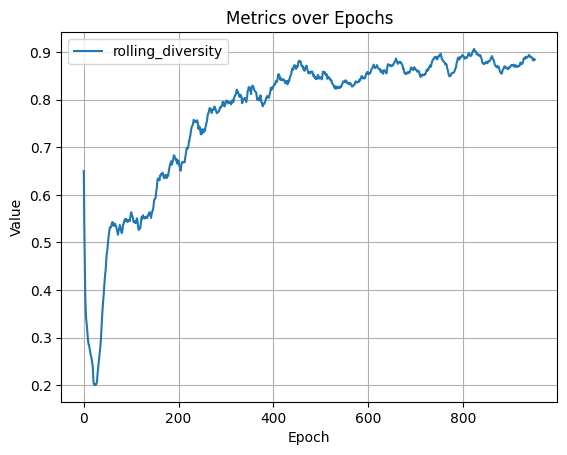

In [5]:
collector.plot(
    # "species.threshold", "count.species", "rate.diversity", "species.evenness"
    # "count.species",
    # "dist_signal",
    # "species_rolling",
    # # "long_rolling",
    # "spec_50_quantile",
    "rolling_diversity",
)

In [6]:
df = collector.to_polars()
df.filter(pl.col("name") == "count.species")

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,generation,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""count.species""",3.0,3.0,3.0,0.0,0.0,NaN,3.0,3.0,1,null,null,null,null,null,null,0,1,"[""species"", ""statistic""]"
"""count.species""",1.0,4.0,2.0,1.414214,2.0,NaN,1.0,3.0,2,null,null,null,null,null,null,1,1,"[""species"", ""statistic""]"
"""count.species""",1.0,5.0,1.666667,1.154701,1.333333,0.0,1.0,3.0,3,null,null,null,null,null,null,2,1,"[""species"", ""statistic""]"
"""count.species""",1.0,6.0,1.5,1.0,1.0,0.0,1.0,3.0,4,null,null,null,null,null,null,3,1,"[""species"", ""statistic""]"
"""count.species""",1.0,7.0,1.4,0.894427,0.8,0.0,1.0,3.0,5,null,null,null,null,null,null,4,1,"[""species"", ""statistic""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""count.species""",3.0,3745.0,3.946259,1.477061,2.181708,3.793566,1.0,15.0,949,null,null,null,null,null,null,948,1,"[""species"", ""statistic""]"
"""count.species""",4.0,3749.0,3.946316,1.476283,2.179412,3.800339,1.0,15.0,950,null,null,null,null,null,null,949,1,"[""species"", ""statistic""]"
"""count.species""",12.0,3761.0,3.954784,1.49844,2.245322,3.855096,1.0,15.0,951,null,null,null,null,null,null,950,1,"[""species"", ""statistic""]"


In [7]:
df = collector.to_polars()
df

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,generation,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""count.evaluation""",8.0,108.0,54.0,65.053825,4232.0,NaN,8.0,100.0,2,null,null,null,null,null,null,0,2,"[""statistic""]"
"""step.evaluate.time""",0.000011,0.000075,0.000038,0.000037,1.3912e-9,NaN,0.000011,0.000064,2,75µs,37µs,37µs,11µs,63µs,0µs,0,2,"[""time"", ""step""]"
"""selector.roulette""",20.0,20.0,20.0,0.0,0.0,NaN,20.0,20.0,1,null,null,null,null,null,null,0,1,"[""selector"", ""statistic""]"
"""selector.roulette.time""",0.000007,0.000007,0.000007,0.0,0.0,NaN,0.000007,0.000007,1,6µs,6µs,0µs,6µs,6µs,0µs,0,1,"[""selector"", ""time""]"
"""selector.tournament""",80.0,80.0,80.0,0.0,0.0,NaN,80.0,80.0,1,null,null,null,null,null,null,0,1,"[""selector"", ""statistic""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""long_rolling""",4.65,3751.37207,3.936382,0.334886,0.112149,0.0,1.4,5.05,953,null,null,null,null,null,null,952,1,"[""statistic"", ""expr""]"
"""spec_50_quantile""",4.666667,3646.381592,3.826214,0.699046,0.488665,0.0,1.0,6.111111,953,null,null,null,null,null,null,952,1,"[""statistic"", ""expr""]"
"""rolling_diversity""",0.884,734.913757,0.771158,0.152904,0.02338,0.0,0.2005,0.9065,953,null,null,null,null,null,null,952,1,"[""statistic"", ""expr""]"


In [8]:
print(result.index())
last_version = df.select("generation").max().item()
last_version

953


952